In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [57]:
df = pd.read_csv("UCI_Credit_Card.csv")

In [58]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## Step 1: Exploration, and Cleaning

In [59]:
df.shape

(30000, 25)

In [60]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month'],
      dtype='str')

In [61]:
# Check how many clients defaulted (1) vs paid on time (0)
print(df['default.payment.next.month'].value_counts())

print(df['default.payment.next.month'].value_counts(normalize=True) * 100)

default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64
default.payment.next.month
0    77.88
1    22.12
Name: proportion, dtype: float64


In [62]:
# Check if there are any empty/null values
missing_values = df.isnull().sum().sum()
print(f"Total missing values found: {missing_values}")

# check of data types to see if any text objects need encoding
print("\nData Types Overview:")
print(df.dtypes.value_counts())

Total missing values found: 0

Data Types Overview:
float64    13
int64      12
Name: count, dtype: int64


### Data Visualization

/var/folders/5j/ylnyz9bj2y5b2w_dnnrsgcx00000gn/T/ipykernel_2655/601990829.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='default.payment.next.month', data=df, palette='Set2')


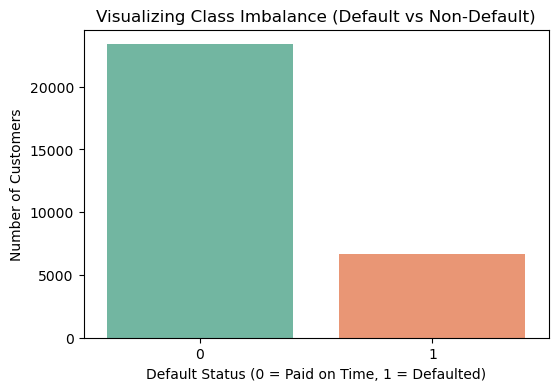

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='default.payment.next.month', data=df, palette='Set2')

plt.title('Visualizing Class Imbalance (Default vs Non-Default)')
plt.xlabel('Default Status (0 = Paid on Time, 1 = Defaulted)')
plt.ylabel('Number of Customers')
plt.show()

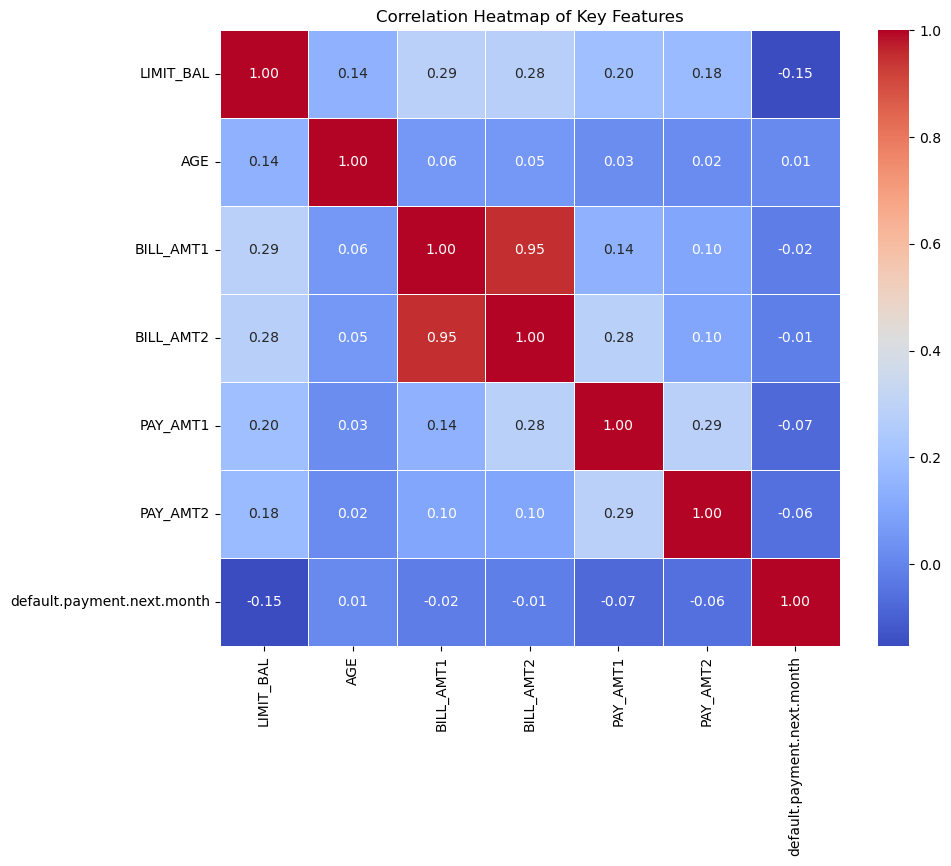

In [66]:
columns_to_look = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'PAY_AMT1', 'PAY_AMT2', 'default.payment.next.month']

plt.figure(figsize=(10, 8))
sns.heatmap(df[columns_to_look].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap of Key Features')
plt.show()

/var/folders/5j/ylnyz9bj2y5b2w_dnnrsgcx00000gn/T/ipykernel_2655/2063949476.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default.payment.next.month', y='LIMIT_BAL', data=df, palette='Pastel1')


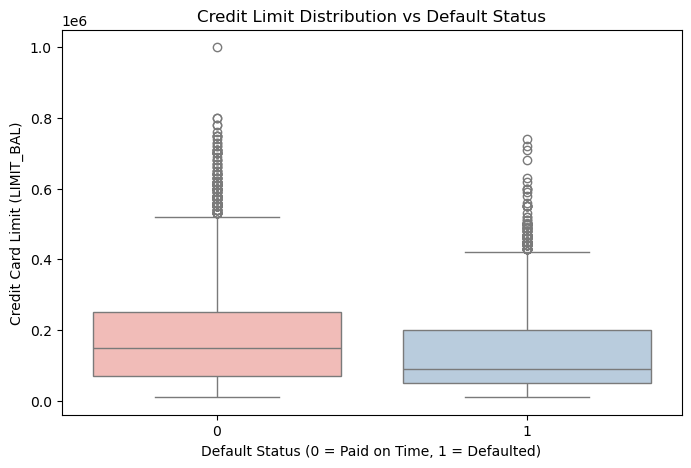

In [67]:
plt.figure(figsize=(8, 5))
# Comparing credit limit distribution across both target classes
sns.boxplot(x='default.payment.next.month', y='LIMIT_BAL', data=df, palette='Pastel1')

plt.title('Credit Limit Distribution vs Default Status')
plt.xlabel('Default Status (0 = Paid on Time, 1 = Defaulted)')
plt.ylabel('Credit Card Limit (LIMIT_BAL)')
plt.show()

In [22]:
X = df.drop(columns=['ID', 'default.payment.next.month'])

y = df['default.payment.next.month']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (30000, 23)
Target (y) shape: (30000,)


In [24]:
# Let's inspect the minimum and maximum values of a few columns to check ranges
print(X[['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']].describe().loc[['min', 'max']])

     LIMIT_BAL   AGE  BILL_AMT1  PAY_AMT1
min    10000.0  21.0  -165580.0       0.0
max  1000000.0  79.0   964511.0  873552.0


In [25]:
X.info

<bound method DataFrame.info of        LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0        20000.0    2          2         1   24      2      2     -1     -1   
1       120000.0    2          2         2   26     -1      2      0      0   
2        90000.0    2          2         2   34      0      0      0      0   
3        50000.0    2          2         1   37      0      0      0      0   
4        50000.0    1          2         1   57     -1      0     -1      0   
...          ...  ...        ...       ...  ...    ...    ...    ...    ...   
29995   220000.0    1          3         1   39      0      0      0      0   
29996   150000.0    1          3         2   43     -1     -1     -1     -1   
29997    30000.0    1          2         2   37      4      3      2     -1   
29998    80000.0    1          3         1   41      1     -1      0      0   
29999    50000.0    1          2         1   46      0      0      0      0   

       PAY_5  ...  

## Step 2: Leak-Free Train-Test Splitting and Scaling.

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    stratify=y, 
    random_state=42
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

Training Features Shape: (24000, 23)
Testing Features Shape: (6000, 23)


In [30]:
# StandardScaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data successfully scaled! Ready for SMOTE.")

Data successfully scaled! Ready for SMOTE.


In [31]:
X_train_scaled

array([[-0.05686623,  0.80844039,  0.18452304, ...,  0.08696116,
         0.50039738,  0.04874486],
       [-0.13408117,  0.80844039, -1.07753249, ..., -0.3180751 ,
        -0.31697847, -0.29299231],
       [-1.21509034, -1.23694958,  0.18452304, ..., -0.29855368,
        -0.29671021, -0.23696983],
       ...,
       [-0.36572599,  0.80844039, -1.07753249, ..., -0.18527633,
        -0.23723448, -0.23696983],
       [ 1.48743258, -1.23694958, -1.07753249, ..., -0.3180751 ,
        -0.31697847, -0.29299231],
       [ 1.02414294, -1.23694958, -1.07753249, ..., -0.3180751 ,
        -0.31697847, -0.29299231]], shape=(24000, 23))

## Step 3: Rebalancing Data with SMOTE.

In [40]:
# Install/update the libraries specifically for this notebook session
!pip install --upgrade imbalanced-learn scikit-learn

In [42]:
import sklearn.utils.validation

# Manually patch the missing function so SMOTE works perfectly
if not hasattr(sklearn.utils.validation, '_is_pandas_df'):
    def _is_pandas_df(X):
        return hasattr(X, "columns") and hasattr(X, "iloc")
    sklearn.utils.validation._is_pandas_df = _is_pandas_df

print("Patch applied successfully! You can now run the SMOTE cell.")

Patch applied successfully! You can now run the SMOTE cell.


In [43]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

# Apply SMOTE only to the training set to avoid data leakage
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Original training target shape:", y_train.value_counts())
print("Balanced training target shape after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Original training target shape: default.payment.next.month
0    18691
1     5309
Name: count, dtype: int64
Balanced training target shape after SMOTE:
default.payment.next.month
0    18691
1    18691
Name: count, dtype: int64


## Step 4: Training the Classification Models

In [45]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)

print("Training Logistic Regression...")
lr_model.fit(X_train_resampled, y_train_resampled)
print("Logistic Regression training complete!")

Training Logistic Regression...
Logistic Regression training complete!


In [46]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("Training Random Forest (this might take a few seconds)...")
rf_model.fit(X_train_resampled, y_train_resampled)
print("Random Forest training complete!")

Training Random Forest (this might take a few seconds)...
Random Forest training complete!


## Step 5: Evaluation.

In [49]:
from sklearn.metrics import classification_report, roc_auc_score

lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

print("LOGISTIC REGRESSION PERFORMANCE")
print(classification_report(y_test, lr_preds, target_names=['No Default', 'Default']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_probs):.4f}")

LOGISTIC REGRESSION PERFORMANCE
              precision    recall  f1-score   support

  No Default       0.87      0.68      0.77      4673
     Default       0.36      0.63      0.46      1327

    accuracy                           0.67      6000
   macro avg       0.61      0.66      0.61      6000
weighted avg       0.75      0.67      0.70      6000

ROC-AUC Score: 0.7104


In [53]:
rf_preds = rf_model.predict(X_test_scaled)
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]

print("RANDOM FOREST PERFORMANCE")
print(classification_report(y_test, rf_preds, target_names=['No Default', 'Default']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_probs):.4f}")

RANDOM FOREST PERFORMANCE
              precision    recall  f1-score   support

  No Default       0.85      0.89      0.87      4673
     Default       0.54      0.46      0.49      1327

    accuracy                           0.79      6000
   macro avg       0.70      0.67      0.68      6000
weighted avg       0.78      0.79      0.79      6000

ROC-AUC Score: 0.7464


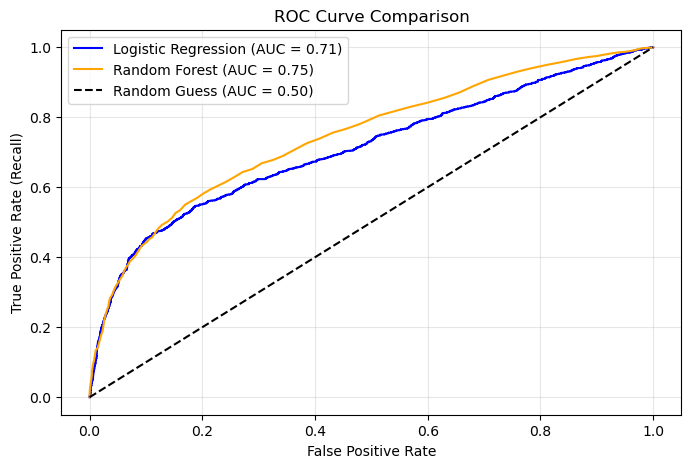

In [55]:
# Plot the ROC Curve to Visualize the Benchmark

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Calculate points for the curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_probs):.2f})', color='blue')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_probs):.2f})', color='orange')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [76]:
# Install the optimized boosting library for this session
!pip install xgboost

In [79]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

# Train on our SMOTE-balanced training data
print("Training XGBoost...")
xgb_model.fit(X_train_resampled, y_train_resampled)
print("XGBoost training complete!")

Training XGBoost...
XGBoost training complete!


In [80]:
from sklearn.metrics import classification_report, roc_auc_score

# Predict on scaled test features
xgb_preds = xgb_model.predict(X_test_scaled)
xgb_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("=== XGBOOST PERFORMANCE ===")
print(classification_report(y_test, xgb_preds, target_names=['No Default', 'Default']))
print(f"New Optimized ROC-AUC Score: {roc_auc_score(y_test, xgb_probs):.4f}")

=== XGBOOST PERFORMANCE ===
              precision    recall  f1-score   support

  No Default       0.85      0.89      0.87      4673
     Default       0.55      0.46      0.50      1327

    accuracy                           0.80      6000
   macro avg       0.70      0.68      0.69      6000
weighted avg       0.79      0.80      0.79      6000

New Optimized ROC-AUC Score: 0.7605


### Final Comparison

In [84]:
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

# Get XGBoost predictions
xgb_preds = xgb_model.predict(X_test_scaled)
xgb_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Extract AUC scores for all three models
auc_lr = roc_auc_score(y_test, lr_probs)
auc_rf = roc_auc_score(y_test, rf_probs)
auc_xgb = roc_auc_score(y_test, xgb_probs)

results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'ROC-AUC Score': [auc_lr, auc_rf, auc_xgb]
}).sort_values(by='ROC-AUC Score', ascending=False)

print("FINAL MODEL COMPARISON")
print(results_df.to_string(index=False))

FINAL MODEL COMPARISON
              Model  ROC-AUC Score
            XGBoost       0.760486
      Random Forest       0.746386
Logistic Regression       0.710420


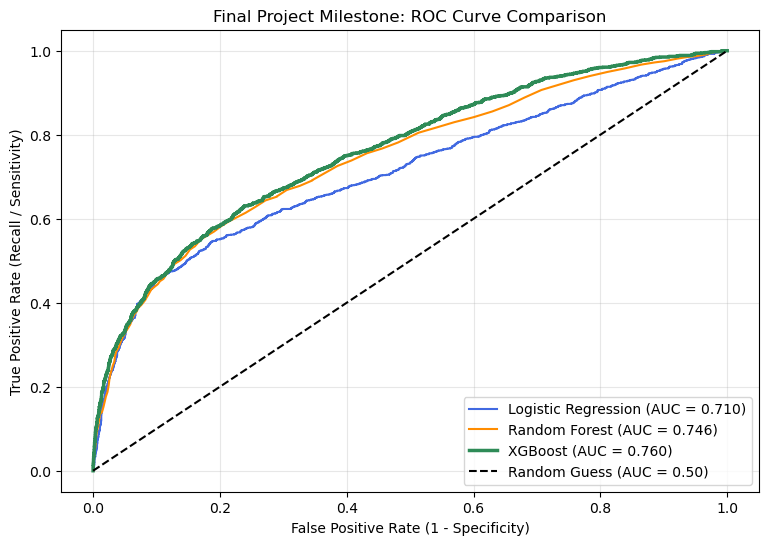

In [85]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Calculate ROC points
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)

# Plotting
plt.figure(figsize=(9, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})', color='royalblue')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', color='darkorange')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})', color='seagreen', linewidth=2.5)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall / Sensitivity)')
plt.title('Final Project Milestone: ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

In [87]:
import joblib

# Automatically identify the model object with the highest score
winning_model_name = results_df.iloc[0]['Model']

if winning_model_name == 'XGBoost':
    final_model = xgb_model
elif winning_model_name == 'Random Forest':
    final_model = rf_model
else:
    final_model = lr_model

# Save both the trained model and the scaler (needed to transform future production data)
joblib.dump(final_model, 'credit_default_best_model.pkl')
joblib.dump(scaler, 'credit_default_scaler.pkl')

print(f"Project Complete! The Optimal model is '{winning_model_name}'.")
print("Successfully exported 'credit_default_best_model.pkl' and 'credit_default_scaler.pkl' to your local directory.")

Project Complete! The Optimal model is 'XGBoost'.
Successfully exported 'credit_default_best_model.pkl' and 'credit_default_scaler.pkl' to your local directory.
